# Hospital Operations, Service & Financial Analytics

## Integrated Hospital Performance & Patient Insights
### End-to-End Healthcare Data Analytics Project

### Project Overview
This project uses hospital data from **patients, visits, and billing** to understand how the hospital is performing from both **operational and patient perspectives**.

The analysis aims to answer key business questions such as:

- What does the hospital's patient population look like?
- Which departments handle the highest patient workload?
- Which areas experience longer waiting times?
- How does waiting time relate to patient satisfaction?
- Which age groups and patient segments generate the most visits?
- What are the major visit and service patterns?
- How do billing and payment patterns affect the hospital's financial performance?
- Where can data help management improve patient service and operational efficiency?

### Project Objectives
The project focuses on four major areas:

**Patient Insights**  
Understand patient demographics, visit patterns, and frequently observed patient groups.

**Operational Performance**  
Analyze department workload, patient flow, waiting times, and length of stay.

**Patient Experience**  
Study satisfaction levels and examine whether service delays are associated with changes in patient satisfaction.

**Financial Visibility**  
Analyze billing amounts, payment behavior, outstanding amounts, and financial patterns across services and patient groups.

### Analytics Approach
Each business question will follow a structured data analyst workflow:

**Business Question → Data Preparation → Analysis → Visualization → Observation → Insight → Recommendation**

Recommendations will be developed **after evaluating the actual analysis results**, rather than making assumptions beforehand.

### Tools & Technologies
**Python | Pandas | NumPy | Data Visualization**

### Expected Outcome
The final outcome will be an **integrated analytical view of hospital performance**, helping identify important patterns in patient demand, operational efficiency, patient experience, and financial activity.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as stats

## 2. Read the Data

In [2]:
# 'keep_default_na=False' treats blank spaces as empty strings rather than native 'NaN's for controlled programmatic evaluation
patients = pd.read_csv('patients.csv', keep_default_na=False)
visits = pd.read_csv('visits.csv', keep_default_na=False)
billing = pd.read_csv('billing.csv', keep_default_na=False)

#describe the table
print('Patients:', patients.shape)
print('Visits:', visits.shape)
print('Billing:', billing.shape)

Patients: (4010, 10)
Visits: (12015, 10)
Billing: (12015, 9)


## 3. Understanding the Data

- Lets us verify features
check data types (like numeric metrics incorrectly stored as text objects), and 
understand the primary-to-foreign key relationships (patient_id and visit_id)

In [3]:
print('\nVISITS')
display(visits.head())
visits.info()


VISITS


,visit_id,patient_id,visit_date,visit_hour,department,diagnosis,visit_type,waiting_time_minutes,length_of_stay_days,satisfaction_score
0,500001,102866,2025-03-07,11,General Medicine,Hypertension Review,Inpatient,44.0,1.0,4.7
1,500002,100602,2025-01-22,13,General Medicine,Diabetes Review,OPD,60.0,0.0,4.4
2,500003,102563,2024-06-04,16,Orthopedics,Sports Injury,Inpatient,28.0,3.0,5.0
3,500004,102617,2024-06-29,7,Gynecology,PCOS,Inpatient,27.0,4.0,5.0
4,500005,100435,2025-04-08,15,General Medicine,Fever,Emergency,37.0,0.0,5.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12015 entries, 0 to 12014
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   visit_id              12015 non-null  int64  
 1   patient_id            12015 non-null  int64  
 2   visit_date            12015 non-null  object 
 3   visit_hour            12015 non-null  int64  
 4   department            12015 non-null  object 
 5   diagnosis             12015 non-null  object 
 6   visit_type            12015 non-null  object 
 7   waiting_time_minutes  12015 non-null  object 
 8   length_of_stay_days   12015 non-null  float64
 9   satisfaction_score    12015 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 938.8+ KB


In [4]:
print('\nBilling')
display(billing.head())
billing.info()


Billing


,bill_id,visit_id,patient_id,bill_amount,insurance_covered_amount,patient_paid_amount,payment_method,payment_status,billing_date
0,800001,500001,102866,7949.6,6172.69,1776.91,Scheme,Paid,2025-03-10
1,800002,500002,100602,1609.59,0.0,1609.59,Card,Paid,2025-01-23
2,800003,500003,102563,26915.56,22533.66,4381.9,Scheme,Partially Paid,2024-06-04
3,800004,500004,102617,20186.36,14645.71,5540.65,UPI,Paid,2024-06-30
4,800005,500005,100435,3098.79,2117.99,980.8,UPI,Paid,2025-04-11


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12015 entries, 0 to 12014
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   bill_id                   12015 non-null  int64 
 1   visit_id                  12015 non-null  int64 
 2   patient_id                12015 non-null  int64 
 3   bill_amount               12015 non-null  object
 4   insurance_covered_amount  12015 non-null  object
 5   patient_paid_amount       12015 non-null  object
 6   payment_method            12015 non-null  object
 7   payment_status            12015 non-null  object
 8   billing_date              12015 non-null  object
dtypes: int64(3), object(6)
memory usage: 844.9+ KB


In [5]:
print('\nPATIENTS')
display(patients.head())
patients.info()


PATIENTS


,patient_id,patient_name,gender,age,city,blood_group,insurance_status,chronic_condition,bmi,registration_date
0,100001,Patient_100001,Male,39,Hyderabad,,Insured,None,30.9,2023-11-20
1,100002,Patient_100002,Male,49,Hyderabad,A+,Government Scheme,Thyroid,18.4,2023-07-04
2,100003,Patient_100003,Female,23,Karimnagar,B+,Insured,None,17.8,2022-06-24
3,100004,Patient_100004,female,52,Secunderabad,O+,Insured,Cardiac,20.4,2025-10-18
4,100005,Patient_100005,Male,41,Nizamabad,O-,Insured,Diabetes,21.5,2022-07-15


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4010 entries, 0 to 4009
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   patient_id         4010 non-null   int64 
 1   patient_name       4010 non-null   object
 2   gender             4010 non-null   object
 3   age                4010 non-null   int64 
 4   city               4010 non-null   object
 5   blood_group        4010 non-null   object
 6   insurance_status   4010 non-null   object
 7   chronic_condition  4010 non-null   object
 8   bmi                4010 non-null   object
 9   registration_date  4010 non-null   object
dtypes: int64(2), object(8)
memory usage: 313.4+ KB


### 4. Blank Character Standardization Across Tables

- Blank Character Standardization Across Tables
- This step replaces all blank strings across the entire dataset with true NumPy null values (np.nan).
- This standardizes the data so we can use efficient missing-value functions like .isna().

In [6]:
# REPLACE BLANKS WITH NAN
patients[['patient_id','patient_name','gender','age','city','blood_group','insurance_status','chronic_condition','bmi','registration_date']] = patients[['patient_id','patient_name','gender','age','city','blood_group','insurance_status','chronic_condition','bmi','registration_date']].replace('',np.nan)
visits[['visit_id','patient_id','visit_date','visit_hour','department','diagnosis','visit_type','waiting_time_minutes','length_of_stay_days','satisfaction_score']] = visits[['visit_id','patient_id','visit_date','visit_hour','department','diagnosis','visit_type','waiting_time_minutes','length_of_stay_days','satisfaction_score']].replace('', np.nan)
billing[['bill_id','visit_id','patient_id','bill_amount','insurance_covered_amount','patient_paid_amount','payment_method','payment_status','billing_date']] = billing[['bill_id','visit_id','patient_id','bill_amount','insurance_covered_amount','patient_paid_amount','payment_method','payment_status','billing_date']].replace('', np.nan)

In [7]:
# Cross check the null values in patient table
patients.isna().sum()

patient_id            0
patient_name          0
gender                0
age                   0
city                 49
blood_group          41
insurance_status      0
chronic_condition     0
bmi                  80
registration_date     0
dtype: int64

In [8]:
visits.isnull().sum()

visit_id                  0
patient_id                0
visit_date                0
visit_hour                0
department               40
diagnosis               120
visit_type                0
waiting_time_minutes    180
length_of_stay_days       0
satisfaction_score      160
dtype: int64

In [9]:
billing.isna().sum()

bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                 150
insurance_covered_amount    180
patient_paid_amount         150
payment_method               90
payment_status                0
billing_date                  0
dtype: int64

### 5. Standardized Object Type Conversion
- This cell converts those columns back to their proper numeric types (integers and floats). The errors='coerce' setting safely converts any unparsable text values directly into NaN

In [10]:
# Convert numeric columns back to numeric
patients['age'] = pd.to_numeric(patients['age'], errors='coerce')
patients['bmi'] = pd.to_numeric(patients['bmi'], errors='coerce')
visits['waiting_time_minutes'] = pd.to_numeric(visits['waiting_time_minutes'], errors='coerce')
visits['satisfaction_score'] = pd.to_numeric(visits['satisfaction_score'], errors='coerce')
visits['length_of_stay_days'] = pd.to_numeric(visits['length_of_stay_days'], errors='coerce')
billing['bill_amount'] = pd.to_numeric(billing['bill_amount'], errors='coerce')
billing['insurance_covered_amount'] = pd.to_numeric(billing['insurance_covered_amount'], errors='coerce')
billing['patient_paid_amount'] = pd.to_numeric(billing['patient_paid_amount'], errors='coerce')
patients['registration_date'] = pd.to_datetime(patients['registration_date'], errors='coerce')


### 6. Duplication Assessment and Null Value Inventory Profiling
- Check for duplicate records and calculate the exact number of missing values across all tables.
- Identifying these pipeline flaws at this stage helps prevent duplicated metrics from skewing our downstream statistical modeling.

In [11]:
print('Patients-missing values')
display(patients.isna().sum())

print('Visits-missing values')
display(visits.isna().sum())

print('Billing-missing values')
display(billing.isna().sum())

print('Patient-duplicates:', patients.duplicated().sum())
print('Visit-duplicates:', visits.duplicated().sum())
print('Billing-duplicates:', billing.duplicated().sum())


Patients-missing values


patient_id            0
patient_name          0
gender                0
age                   0
city                 49
blood_group          41
insurance_status      0
chronic_condition     0
bmi                  80
registration_date     0
dtype: int64

Visits-missing values


visit_id                  0
patient_id                0
visit_date                0
visit_hour                0
department               40
diagnosis               120
visit_type                0
waiting_time_minutes    180
length_of_stay_days       0
satisfaction_score      160
dtype: int64

Billing-missing values


bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                 150
insurance_covered_amount    180
patient_paid_amount         150
payment_method               90
payment_status                0
billing_date                  0
dtype: int64

Patient-duplicates: 10
Visit-duplicates: 15
Billing-duplicates: 15


## Data Cleaning

### Clean Patients Data

### 7. Patient Registry Deduplication

In [12]:
# Purge identical duplicated observations to fix baseline row counts
patients = patients.drop_duplicates()

### 8. Text Field Variation and Inconsistency Verification

In [13]:
# Review unique text inputs to discover manual text discrepancies
list_of_string_col = ['gender', 'city', 'blood_group', 'insurance_status', 'chronic_condition']

for col in list_of_string_col:
    print("The unique values in", col, patients[col].unique())

The unique values in gender ['Male' 'Female' 'female' 'FEMALE' 'M']
The unique values in city ['Hyderabad' 'Karimnagar' 'Secunderabad' 'Nizamabad' nan 'Warangal'
 'HYDERABAD' ' hyderabad ']
The unique values in blood_group [nan 'A+' 'B+' 'O+' 'O-' 'AB-' 'A-' 'AB+' 'B-']
The unique values in insurance_status ['Insured' 'Government Scheme' 'Self Pay']
The unique values in chronic_condition ['None' 'Thyroid' 'Cardiac' 'Diabetes' 'Hypertension' 'Asthma']


In [14]:
print(patients['gender'].unique())
print(patients['city'].unique())

['Male' 'Female' 'female' 'FEMALE' 'M']
['Hyderabad' 'Karimnagar' 'Secunderabad' 'Nizamabad' nan 'Warangal'
 'HYDERABAD' ' hyderabad ']


### 9. Categorical Case Normalization: Patient Gender

In [15]:
#  Standardizing labels ('Male' or 'Female')
patients['gender'] = patients['gender'].replace({
    'M':'Male',
    'female':'Female',
    'FEMALE':'Female'
})

In [16]:
patients['gender'].unique()


array(['Male', 'Female'], dtype=object)

### 10. Geographic Structural Optimization: Text Trimming & Capitalization

In [17]:
# Remove trailing or leading spaces and apply unified title casing
patients['city'] = patients['city'].str.strip().str.title()

In [18]:
patients['city'].unique()

array(['Hyderabad', 'Karimnagar', 'Secunderabad', 'Nizamabad', nan,
       'Warangal'], dtype=object)

### 11. Biological Outlier Isolation: Age Validity Verification

In [19]:
patients.loc[(patients['age'] < 1) | (patients['age'] > 100), 'age'] 

45      125
193      -4
1021    125
1050     -4
1421     -4
1684     -4
2697    125
2803     -4
2891    125
2915    125
3084    125
3085     -4
3169     -4
3969    125
Name: age, dtype: int64

### 12. Stratified Age Imputation via Chronic Condition Groupings

In [20]:
# Coerce invalid age metrics to missing data points for context imputation
patients.loc[(patients['age'] < 1) | (patients['age'] > 100), 'age'] = np.nan

In [21]:
# Cross check
patients.loc[(patients['age'] < 1) | (patients['age'] > 100), 'age'] 

Series([], Name: age, dtype: float64)

In [22]:
display(
    patients.groupby('chronic_condition')['age']
            .median()
            .sort_values()
)

chronic_condition
None            43.0
Asthma          44.0
Thyroid         49.0
Diabetes        51.0
Hypertension    54.0
Cardiac         56.0
Name: age, dtype: float64

In [23]:
patients['chronic_condition'].unique()

array(['None', 'Thyroid', 'Cardiac', 'Diabetes', 'Hypertension', 'Asthma'],
      dtype=object)

- It calculates the median age for each specific chronic condition group and applies that group median to any missing values within it. 
- Any remaining unassigned slots are safely filled with the overall dataset median.

In [24]:
age_median = patients.groupby('chronic_condition')['age'].median()

for condition in patients['chronic_condition'].unique():
    value = age_median[condition]

    mask = (
        patients['age'].isna() &
        patients['chronic_condition'].eq(condition)
    )

    patients.loc[mask, 'age'] = value

In [25]:
patients['age'].isnull().sum()

np.int64(0)

In [26]:
# still have the missing vlaues then use the overall medain to replace the missing vlaues 

patients['age'] = patients['age'].fillna(patients['age'].median())
patients['age'] = patients['age'].round().astype(int)

### 13. Feature Engineering: Demographic Generation Lifecycles

- this step groups continuous patient ages into meaningful life-stage buckets
- Discretizing this data helps analysts track systemic clinical trends across broader generational groups rather than individual ages.

In [27]:
patients['age_group'] = pd.cut(
    patients['age'],
    bins=[0,17,30,45,60,100],
    labels=['0-17','18-30','31-45','46-60','60+']
)

### 14. Body Mass Index Outlier Resolution & Target Cohort Imputation
- This section scans for invalid Body Mass Index entries (such as values below 12 or above 55) and marks them as missing. It then fills those gaps by calculating the median BMI for each patient's specific age group, ensuring our health profile records remain clinically accurate.

In [28]:
# Reset impossible clinical BMI entries to missing values
patients.loc[(patients['bmi'] < 12) | (patients['bmi'] > 55), 'bmi'] = np.nan

In [29]:
# Calculate context-aware median BMI values across demographic age groups
bmi_median = patients.groupby('age_group')['bmi'].median()

for group in patients['age_group'].dropna().unique():
    mask = (
        patients['bmi'].isna() &
        patients['age_group'].eq(group)
    )

    patients.loc[mask, 'bmi'] = bmi_median[group]

# Handle remaining empty records using the overall global median
patients['bmi'] = patients['bmi'].fillna(patients['bmi'].median())

C:\Users\shash\AppData\Local\Temp\ipykernel_11776\1486911502.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_median = patients.groupby('age_group')['bmi'].median()


In [30]:
patients.isnull().sum()

patient_id            0
patient_name          0
gender                0
age                   0
city                 49
blood_group          40
insurance_status      0
chronic_condition     0
bmi                   0
registration_date     0
age_group             0
dtype: int64

### 15. Categorical Missing Field Resolution

In [31]:
# Replace structural empty string variables with unknown labels
# This ensures we keep these rows intact for global aggregations instead of dropping them entirely

patients['city'] = patients['city'].fillna('Unknown')
patients['blood_group'] = patients['blood_group'].fillna('Unknown')

## Clean Visits Data

### 16. Structural Validation of Clinical Visits Logging
 - It processes the visits dataset by removing duplicate rows, transforming raw string dates into functional Pandas datetime objects, and normalizing department names to uniform Title Case.

In [32]:
# here we remove the duplicates 
visits = visits.drop_duplicates().copy()

In [33]:
visits['visit_date'] = pd.to_datetime(visits['visit_date'], errors='coerce')
visits['department'] = visits['department'].str.strip().str.title()
visits.head()

,visit_id,patient_id,visit_date,visit_hour,department,diagnosis,visit_type,waiting_time_minutes,length_of_stay_days,satisfaction_score
0,500001,102866,2025-03-07,11,General Medicine,Hypertension Review,Inpatient,44.0,1.0,4.7
1,500002,100602,2025-01-22,13,General Medicine,Diabetes Review,OPD,60.0,0.0,4.4
2,500003,102563,2024-06-04,16,Orthopedics,Sports Injury,Inpatient,28.0,3.0,5.0
3,500004,102617,2024-06-29,7,Gynecology,PCOS,Inpatient,27.0,4.0,5.0
4,500005,100435,2025-04-08,15,General Medicine,Fever,Emergency,37.0,0.0,5.0


### 17. Structural Operations Logic Constraining
- Here we removes obvious data entry errors from the operations such as negative wait times or customer satisfaction ratings outside the standard 1 to 5 range—by turning them into missing fields (NaN) for cleaner processing downstream.

In [34]:
# Convert impossible values to Nan
visits.loc[visits['waiting_time_minutes'] <= 0, 'waiting_time_minutes'] = np.nan
visits.loc[(visits['satisfaction_score'] < 1) | (visits['satisfaction_score'] > 5), 'satisfaction_score'] = np.nan
visits.loc[visits['length_of_stay_days'] < 0, 'length_of_stay_days'] = np.nan

### 18. Medical Department Imputation via Diagnosis Cross-Filling
- Here we observe the relation between diagnosis and the department
- When a clinic department field is missing but the diagnosis is available, then fills the gap by looking up the most frequent department associated with that specific diagnosis.

In [35]:
# Identify the most frequent department associated with each diagnosis
diagnosis_department = (
    visits.dropna(subset=['diagnosis','department'])
          .groupby('diagnosis')['department']
          .agg(lambda x: x.mode()[0])
)


In [36]:
# Apply the mapping to fill missing department values
mask = visits['department'].isna() & visits['diagnosis'].notna()

visits.loc[mask, 'department'] = visits.loc[mask, 'diagnosis'].map(diagnosis_department)

visits['department'] = visits['department'].fillna('Unknown')


In [37]:
visits.isna().sum()

visit_id                  0
patient_id                0
visit_date                0
visit_hour                0
department                0
diagnosis               120
visit_type                0
waiting_time_minutes    192
length_of_stay_days       8
satisfaction_score      170
dtype: int64

### 19. Clinical Diagnosis Imputation via Department Association
- Similarly, if a clinical diagnosis is missing but the department is known, this cell replaces the missing value with the most common diagnosis recorded for that specific medical specialty.

In [38]:
department_diagnosis = (
    visits.dropna(subset=['diagnosis'])
          .groupby('department')['diagnosis']
          .agg(lambda x: x.mode()[0])
)

department_diagnosis

department
Cardiology          Coronary Artery Disease
General Medicine                      Fever
Gynecology               Menstrual Disorder
Orthopedics                        Fracture
Pediatrics                          Allergy
Pulmonology                            COPD
Name: diagnosis, dtype: object

In [39]:
mask = visits['diagnosis'].isna()

visits.loc[mask, 'diagnosis'] = visits.loc[mask, 'department'].map(department_diagnosis)

visits['diagnosis'] = visits['diagnosis'].fillna('Unknown')


In [40]:
visits.isna().sum()

visit_id                  0
patient_id                0
visit_date                0
visit_hour                0
department                0
diagnosis                 0
visit_type                0
waiting_time_minutes    192
length_of_stay_days       8
satisfaction_score      170
dtype: int64

### 20. Operational Wait Imputation via Segment Medians
- This block resolves missing patient wait times by calculating the median wait duration stratified by both department and visit type (for example, Emergency visits vs regular Outpatient appointments). This ensures the imputed times match operational realities.

In [41]:
# Generate localized median wait-times across core operational metrics
wait_median = visits.groupby(
    ['department','visit_type']
)['waiting_time_minutes'].median()

wait_median

department        visit_type
Cardiology        Emergency     48.0
                  Inpatient     56.0
                  OPD           60.0
General Medicine  Emergency     40.5
                  Inpatient     48.0
                  OPD           52.0
Gynecology        Emergency     28.0
                  Inpatient     33.0
                  OPD           39.0
Orthopedics       Emergency     29.0
                  Inpatient     38.0
                  OPD           42.5
Pediatrics        Emergency     23.0
                  Inpatient     32.0
                  OPD           36.0
Pulmonology       Emergency     36.0
                  Inpatient     42.0
                  OPD           46.0
Name: waiting_time_minutes, dtype: float64

In [42]:
# Apply these granular operational medians to empty records
for department in visits['department'].unique():
    for visit_type in visits['visit_type'].unique():

        value = wait_median.get((department, visit_type))

        mask = (
            visits['waiting_time_minutes'].isna() &
            visits['department'].eq(department) &
            visits['visit_type'].eq(visit_type)
        )

        visits.loc[mask, 'waiting_time_minutes'] = value

# Fill any remaining edge cases with the overall global median wait time
visits['waiting_time_minutes'] =     visits['waiting_time_minutes'].fillna(
        visits['waiting_time_minutes'].median()
    )


In [43]:
visits.isna().sum()

visit_id                  0
patient_id                0
visit_date                0
visit_hour                0
department                0
diagnosis                 0
visit_type                0
waiting_time_minutes      0
length_of_stay_days       8
satisfaction_score      170
dtype: int64

### 21. Feature Engineering: Service Quality Wait Time Band
- This cell groups continuous wait times into qualitative operational categories (<=20, 21-40, etc.). 
- This grouping makes it easy to analyze how long wait times impact patient satisfaction.

In [44]:
# Segment individual wait times into standardized service level bins
visits['wait_band'] = pd.cut(
    visits['waiting_time_minutes'],
    bins=[0,20,40,60,10000],
    labels=['<=20','21-40','41-60','60+']
)

### 22. Patient Satisfaction Score Reconstruction
- This step repairs missing patient satisfaction scores by using the median rating from other visits within the same department.
- This technique preserves the natural correlation between long wait times and lower experience scores.

In [45]:
satisfaction_median = visits.groupby(
    ['department','wait_band'])['satisfaction_score'].median()

satisfaction_median

C:\Users\shash\AppData\Local\Temp\ipykernel_11776\3924631001.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  satisfaction_median = visits.groupby(


department        wait_band
Cardiology        <=20         4.90
                  21-40        4.60
                  41-60        4.30
                  60+          4.10
General Medicine  <=20         4.80
                  21-40        4.60
                  41-60        4.30
                  60+          4.10
Gynecology        <=20         4.80
                  21-40        4.60
                  41-60        4.40
                  60+          4.00
Orthopedics       <=20         4.80
                  21-40        4.60
                  41-60        4.30
                  60+          4.05
Pediatrics        <=20         4.80
                  21-40        4.60
                  41-60        4.40
                  60+          4.10
Pulmonology       <=20         4.90
                  21-40        4.60
                  41-60        4.30
                  60+          4.10
Name: satisfaction_score, dtype: float64

In [46]:
# Map matching satisfaction medians onto the missing records
for department in visits['department'].unique():
    for band in visits['wait_band'].dropna().unique():

        value = satisfaction_median.get((department, band))

        mask = (
            visits['satisfaction_score'].isna() &
            visits['department'].eq(department) &
            visits['wait_band'].eq(band)
        )

        visits.loc[mask, 'satisfaction_score'] = value

# Resolve any leftover edge cases using the overall dataset median
visits['satisfaction_score'] = visits['satisfaction_score'].fillna(
        visits['satisfaction_score'].median()
    )


In [47]:
# cross check 
visits.isnull().sum()

visit_id                0
patient_id              0
visit_date              0
visit_hour              0
department              0
diagnosis               0
visit_type              0
waiting_time_minutes    0
length_of_stay_days     8
satisfaction_score      0
wait_band               0
dtype: int64

# Clean Billing Data

### 23. Financial Invoiced Processing and Cleaning

In [48]:
# Clean billing records by dropping exact duplicates
billing = billing.drop_duplicates().copy()

# Convert invoice logs to standard Pandas datetime fields
billing['billing_date'] = pd.to_datetime(
    billing['billing_date'],
    errors='coerce'
)

billing.head()

,bill_id,visit_id,patient_id,bill_amount,insurance_covered_amount,patient_paid_amount,payment_method,payment_status,billing_date
0,800001,500001,102866,7949.60,6172.69,1776.91,Scheme,Paid,2025-03-10
1,800002,500002,100602,1609.59,0.00,1609.59,Card,Paid,2025-01-23
2,800003,500003,102563,26915.56,22533.66,4381.90,Scheme,Partially Paid,2024-06-04
3,800004,500004,102617,20186.36,14645.71,5540.65,UPI,Paid,2024-06-30
4,800005,500005,100435,3098.79,2117.99,980.80,UPI,Paid,2025-04-11


In [49]:
billing['payment_method'].unique()

array(['Scheme', 'Card', 'UPI', 'Cash', 'Insurance', nan], dtype=object)

### 24. Transaction Field Casing Normalization
- This step converts payment method text entries into a uniform case format('Upi' as 'UPI')

In [50]:
billing['payment_method'] = billing['payment_method'].str.strip().str.title()


In [51]:
# Check for invalid negative values in financial entries
billing.loc[billing['bill_amount'] <= 0, 'bill_amount']

126    -500.0
626    -500.0
716    -500.0
6353   -500.0
6797   -500.0
6933   -500.0
8037   -500.0
9571   -500.0
Name: bill_amount, dtype: float64

In [52]:
billing.loc[billing['patient_paid_amount'] < 0, 'patient_paid_amount']

874     -100.0
2057    -100.0
2613    -100.0
5639    -100.0
5930    -100.0
7176    -100.0
9368    -100.0
10818   -100.0
Name: patient_paid_amount, dtype: float64

In [53]:
# Reset these billing anomalies to missing values for reconstruction
billing.loc[billing['bill_amount'] <= 0, 'bill_amount'] = np.nan
billing.loc[billing['patient_paid_amount'] < 0, 'patient_paid_amount'] = np.nan

billing.isna().sum()

bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                 158
insurance_covered_amount    180
patient_paid_amount         158
payment_method               90
payment_status                0
billing_date                  0
dtype: int64

### 26. Invoice Value Reconstruction via Department Medians
- To fix missing invoice totals, this code first pulls operational variables (department and visit type) into the billing dataset. 
- It then calculates the median cost for each specific operational segment and uses those figures to accurately fill the missing invoice amounts

In [54]:
# Merge clinical location attributes into the financial billing frame
billing = billing.merge(
    visits[['visit_id','department','visit_type']],
    on='visit_id',
    how='left'
)

In [55]:
# Calculate typical cost profiles stratified by department and visit type
bill_median = billing.groupby(
    ['department','visit_type']
)['bill_amount'].median()

bill_median

department        visit_type
Cardiology        Emergency      7637.890
                  Inpatient     32958.105
                  OPD            3748.830
General Medicine  Emergency      2566.115
                  Inpatient     23005.610
                  OPD            1308.235
Gynecology        Emergency      4539.935
                  Inpatient     26307.570
                  OPD            2345.100
Orthopedics       Emergency      6050.125
                  Inpatient     28386.435
                  OPD            3085.245
Pediatrics        Emergency      2888.870
                  Inpatient     22684.420
                  OPD            1409.850
Pulmonology       Emergency      4962.460
                  Inpatient     26927.060
                  OPD            2460.655
Name: bill_amount, dtype: float64

In [56]:
# Apply these typical cost medians to the missing bill amounts
for department in billing['department'].unique():
    for visit_type in billing['visit_type'].unique():

        value = bill_median.get((department, visit_type))

        mask = (
            billing['bill_amount'].isna() &
            billing['department'].eq(department) &
            billing['visit_type'].eq(visit_type)
        )

        billing.loc[mask, 'bill_amount'] = value

# Clear any leftover records with the overall global median bill amount
billing['bill_amount'] = billing['bill_amount'].fillna(billing['bill_amount'].median())

billing.isnull().sum()


bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                   0
insurance_covered_amount    180
patient_paid_amount         158
payment_method               90
payment_status                0
billing_date                  0
department                    0
visit_type                    0
dtype: int64

### 27. Claim Payer Coverage Recovery Modeling
- Here forces coverage amounts to 0 for any 'Self Pay' classifications
- Ensuring we don't accidentally assign insurance payouts to uninsured accounts.

In [57]:
# Merge patient insurance statuses into the billing records
billing = billing.merge(
    patients[['patient_id','insurance_status']],
    on='patient_id',
    how='left'
)

In [58]:
mask = (
    billing['insurance_covered_amount'].isna() &
    billing['insurance_status'].eq('Self Pay')
)

billing.loc[mask, 'insurance_covered_amount']

185     NaN
646     NaN
853     NaN
960     NaN
1400    NaN
         ..
10886   NaN
11248   NaN
11468   NaN
11491   NaN
11756   NaN
Name: insurance_covered_amount, Length: 61, dtype: float64

In [59]:
# Set insurance coverage to zero for all Self Pay records
mask = (
    billing['insurance_covered_amount'].isna() &
    billing['insurance_status'].eq('Self Pay')
)

billing.loc[mask, 'insurance_covered_amount'] = 0

billing.isna().sum()


bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                   0
insurance_covered_amount    119
patient_paid_amount         158
payment_method               90
payment_status                0
billing_date                  0
department                    0
visit_type                    0
insurance_status              0
dtype: int64

### 28. Payer Group Claim Ratio Imputation
- This section calculates historical insurance coverage percentages for existing records across different insurance tiers. 
- It then applies those specific coverage ratios to fill any missing insurance payout amounts based on the patient's insurance type.

In [60]:
billing['coverage_pct'] = (
    billing['insurance_covered_amount'] /
    billing['bill_amount']
)
billing.head()

,bill_id,visit_id,patient_id,bill_amount,insurance_covered_amount,patient_paid_amount,payment_method,payment_status,billing_date,department,visit_type,insurance_status,coverage_pct
0,800001,500001,102866,7949.60,6172.69,1776.91,Scheme,Paid,2025-03-10,General Medicine,Inpatient,Government Scheme,0.776478
1,800002,500002,100602,1609.59,0.00,1609.59,Card,Paid,2025-01-23,General Medicine,OPD,Self Pay,0.000000
2,800003,500003,102563,26915.56,22533.66,4381.90,Scheme,Partially Paid,2024-06-04,Orthopedics,Inpatient,Government Scheme,0.837198
3,800004,500004,102617,20186.36,14645.71,5540.65,Upi,Paid,2024-06-30,Gynecology,Inpatient,Insured,0.725525
4,800005,500005,100435,3098.79,2117.99,980.80,Upi,Paid,2025-04-11,General Medicine,Emergency,Insured,0.683489


In [61]:
# Use these median rates to reconstruct missing insurance payout amounts
coverage_median = billing.groupby(
    'insurance_status'
)['coverage_pct'].median()


coverage_median

insurance_status
Government Scheme    0.824290
Insured              0.684064
Self Pay             0.000000
Name: coverage_pct, dtype: float64

In [62]:
for payer in ['Insured','Government Scheme']:

    mask = (
        billing['insurance_covered_amount'].isna() &
        billing['insurance_status'].eq(payer)
    )

    billing.loc[mask, 'insurance_covered_amount'] = (
        billing.loc[mask, 'bill_amount'] *coverage_median[payer]
    )
# Fill any remaining unassigned fields with 0
billing['insurance_covered_amount'] = billing['insurance_covered_amount'].fillna(0)


In [63]:
billing.isnull().sum()

bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                   0
insurance_covered_amount      0
patient_paid_amount         158
payment_method               90
payment_status                0
billing_date                  0
department                    0
visit_type                    0
insurance_status              0
coverage_pct                119
dtype: int64

In [64]:
mask = billing['patient_paid_amount'].isna()

billing.loc[mask, 'patient_paid_amount']

21      NaN
71      NaN
104     NaN
138     NaN
180     NaN
         ..
11675   NaN
11814   NaN
11827   NaN
11859   NaN
11883   NaN
Name: patient_paid_amount, Length: 158, dtype: float64

### 29. Out-of-Pocket Balance Equation Resolution
- This cell recalculates missing patient out-of-pocket costs by (total bill amount - insurance coverage)

In [65]:
# Reconstruct missing out-of-pocket values using total bills and insurance coverages
mask = billing['patient_paid_amount'].isna()

billing.loc[mask, 'patient_paid_amount'] = (
    billing.loc[mask, 'bill_amount'] -
    billing.loc[mask, 'insurance_covered_amount']
)

# Prevent negative numbers by capping the minimum value at 0
billing['patient_paid_amount'] = billing['patient_paid_amount'].clip(lower=0)


In [66]:
billing.isna().sum()

bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                   0
insurance_covered_amount      0
patient_paid_amount           0
payment_method               90
payment_status                0
billing_date                  0
department                    0
visit_type                    0
insurance_status              0
coverage_pct                119
dtype: int64

### 30. Construction of the Master Analytical DataFrame
- Now that all individual frames are clean, and merges them into a single, comprehensive Master DataFrame

In [67]:
df = visits.merge(
    patients,
    on='patient_id',
    how='left'
)

In [68]:
# Add matching financial entries using verified composite keys
df = df.merge(
    billing[
        ['visit_id','patient_id','bill_amount',
         'insurance_covered_amount','patient_paid_amount',
         'payment_method','payment_status','billing_date']
    ],
    on=['visit_id','patient_id'],
    how='left'
)

print(df.shape)
display(df.head())


(12000, 27)


,visit_id,patient_id,visit_date,visit_hour,department,diagnosis,visit_type,waiting_time_minutes,length_of_stay_days,satisfaction_score,...,chronic_condition,bmi,registration_date,age_group,bill_amount,insurance_covered_amount,patient_paid_amount,payment_method,payment_status,billing_date
0,500001,102866,2025-03-07,11,General Medicine,Hypertension Review,Inpatient,44.0,1.0,4.7,...,None,28.8,2025-02-19,18-30,7949.60,6172.69,1776.91,Scheme,Paid,2025-03-10
1,500002,100602,2025-01-22,13,General Medicine,Diabetes Review,OPD,60.0,0.0,4.4,...,None,17.0,2022-02-12,60+,1609.59,0.00,1609.59,Card,Paid,2025-01-23
2,500003,102563,2024-06-04,16,Orthopedics,Sports Injury,Inpatient,28.0,3.0,5.0,...,None,24.3,2025-01-18,46-60,26915.56,22533.66,4381.90,Scheme,Partially Paid,2024-06-04
3,500004,102617,2024-06-29,7,Gynecology,PCOS,Inpatient,27.0,4.0,5.0,...,None,25.3,2023-10-10,31-45,20186.36,14645.71,5540.65,Upi,Paid,2024-06-30
4,500005,100435,2025-04-08,15,General Medicine,Fever,Emergency,37.0,0.0,5.0,...,Asthma,28.2,2025-03-04,46-60,3098.79,2117.99,980.80,Upi,Paid,2025-04-11


### 31. Feature Engineering: Daily Shifts Allocation
- This step breaks down raw admission hours into operational shifts (Morning, Midday, etc.).
- This grouping helps managers easily map team scheduling levels to peak patient arrival windows.

In [69]:
# Discretize continuous arrival hours into operational shifts
df['visit_time_band'] = pd.cut(
    df['visit_hour'],
    bins=[0,6,11,16,20,24],
    labels=['Night','Morning','Midday','Evening','Late Evening'],
    right=False
)

### 32. Relative Patient Financial Burden Ratio
- Here we calculates the percentage of the medical bill paid out-of-pocket by the patient
- This financial metric highlights patient affordability levels and potential collection risks across different income segments.

In [70]:
df['out_of_pocket_pct'] = (
    df['patient_paid_amount'] / df['bill_amount'] * 100).round(1)

# cross chekc 
df.head(2)

,visit_id,patient_id,visit_date,visit_hour,department,diagnosis,visit_type,waiting_time_minutes,length_of_stay_days,satisfaction_score,...,registration_date,age_group,bill_amount,insurance_covered_amount,patient_paid_amount,payment_method,payment_status,billing_date,visit_time_band,out_of_pocket_pct
0,500001,102866,2025-03-07,11,General Medicine,Hypertension Review,Inpatient,44.0,1.0,4.7,...,2025-02-19,18-30,7949.60,6172.69,1776.91,Scheme,Paid,2025-03-10,Midday,22.4
1,500002,100602,2025-01-22,13,General Medicine,Diabetes Review,OPD,60.0,0.0,4.4,...,2022-02-12,60+,1609.59,0.00,1609.59,Card,Paid,2025-01-23,Midday,100.0


### 33. Service Level Agreement Breach Flags
- This line sets up an operational flag that instantly highlights any wait times longer than 60 minutes.
- This allows tracking of service level breaches without manually sorting through raw times.

In [71]:
# Flag service level breaches where wait times exceed 60 minutes
df['high_wait_flag'] = np.where(
    df['waiting_time_minutes'] > 60,
    'High Wait',
    'Normal Wait'
)


In [72]:
patient_visit_count = df.groupby(
    'patient_id'
)['visit_id'].transform('count')
patient_visit_count

0        6
1        3
2        2
3        5
4        2
        ..
11995    2
11996    3
11997    2
11998    3
11999    7
Name: visit_id, Length: 12000, dtype: int64

### 34. Patient Institutional Loyalty Classification
- Checks the total number of visits per patient to automatically categorize them as either a 'Repeat' regular or a 'Single Visit' patient
- This classification helps track retention rates and distinguish long-term chronic care needs from one-time emergency visits.

In [73]:
# Calculate the total number of historical visits for each individual patient
patient_visit_count = df.groupby(
    'patient_id'
)['visit_id'].transform('count')

patient_visit_count

0        6
1        3
2        2
3        5
4        2
        ..
11995    2
11996    3
11997    2
11998    3
11999    7
Name: visit_id, Length: 12000, dtype: int64

In [74]:
# Categorize patients based on their operational interaction rates
df['repeat_patient'] = np.where(
    patient_visit_count > 1,
    'Repeat',
    'Single Visit'
)


In [75]:
df['chronic_condition'].unique()

array(['None', 'Asthma', 'Hypertension', 'Diabetes', 'Thyroid', 'Cardiac'],
      dtype=object)

### 35. Final Data Integrity System Verification Run
- This final cell runs a comprehensive data integrity sweep across our primary tables, confirming that all missing values, formatting discrepancies, and logic errors have been resolved.
- The dataset is now clean and ready for reporting or predictive modeling.

In [76]:
print(billing.isna().sum())
print(visits.isna().sum())
print(patients.isna().sum())

bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                   0
insurance_covered_amount      0
patient_paid_amount           0
payment_method               90
payment_status                0
billing_date                  0
department                    0
visit_type                    0
insurance_status              0
coverage_pct                119
dtype: int64
visit_id                0
patient_id              0
visit_date              0
visit_hour              0
department              0
diagnosis               0
visit_type              0
waiting_time_minutes    0
length_of_stay_days     8
satisfaction_score      0
wait_band               0
dtype: int64
patient_id           0
patient_name         0
gender               0
age                  0
city                 0
blood_group          0
insurance_status     0
chronic_condition    0
bmi                  0
registration_date    0
age_group            0
dtype: int64


# 3. Exploratory Data Analysis

## 1. Univariate Analysis
- Univariate analysis studies **one variable at a time**. We first understand the distribution, then decide whether the result matters to the business.


### 1.1 Age- Which age group uses the hospital the most?


age_group
0-17      545
18-30    1583
31-45    3512
46-60    3682
60+      2678
Name: count, dtype: int64

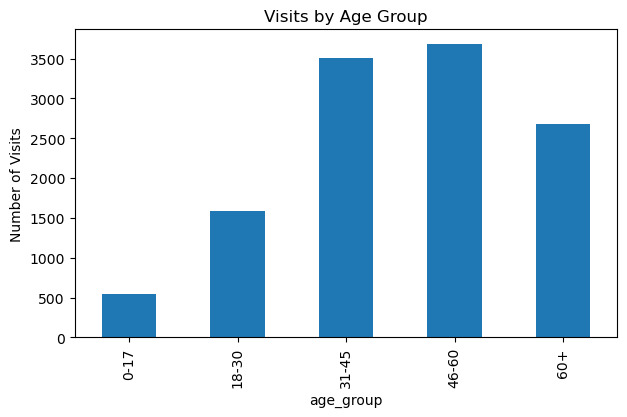

In [77]:
age_analysis = df['age_group'].value_counts().sort_index()
display(age_analysis)

plt.figure(figsize=(7,4))
age_analysis.plot(kind='bar')
plt.title('Visits by Age Group')
plt.ylabel('Number of Visits')
plt.show()

**Observation:** The 46-60 age group is the largest (3,682 visits) and 0-17 is the smallest (545 visits).

**Insight:** The hospital serves mostly a middle-aged to older adult population, not a pediatric-heavy one.

**Recommendation:** Size staffing/specialty capacity (Cardiology, Orthopedics) around the 46+ demographic, which dominates volume.

### 1.2 Department - where is the patient load concentrated?

department
General Medicine    3535
Orthopedics         1979
Cardiology          1914
Pulmonology         1631
Gynecology          1489
Pediatrics          1452
Name: count, dtype: int64

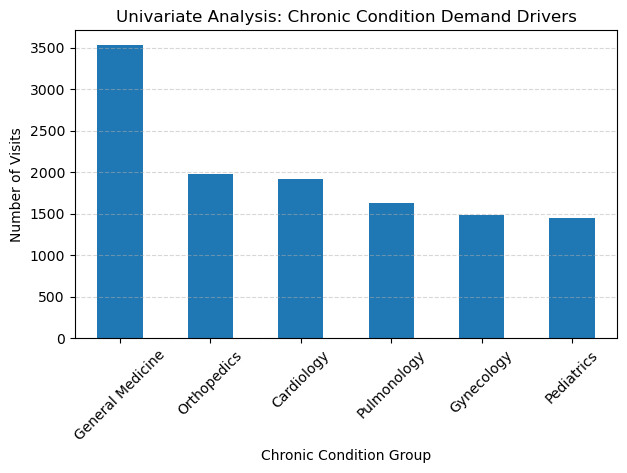

In [78]:
# Chronic Conditions Driving Demand
chronic_drivers = visits['department'].value_counts()
display(chronic_drivers)

plt.figure(figsize=(7, 4))
chronic_drivers.plot(kind='bar')
plt.title('Univariate Analysis: Chronic Condition Demand Drivers')
plt.xlabel('Chronic Condition Group')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


**Observation:** General Medicine dominates at 3,535 visits, nearly double Orthopedics (1,979). Pediatrics is smallest at 1,452.

**Insight:** Load is heavily concentrated in one department — a bottleneck in General Medicine affects roughly twice as many patients as the same bottleneck anywhere else.

**Recommendation:** Give General Medicine first priority for any throughput or staffing improvement, since gains there scale across the largest patient base.
Create specialized educational programs and monitoring desks for highly active conditions like Hypertension and Diabetes.

### 1.3 Waiting-Time Severity Assessment

wait_band
<=20      739
21-40    3989
41-60    5454
60+      1818
Name: count, dtype: int64

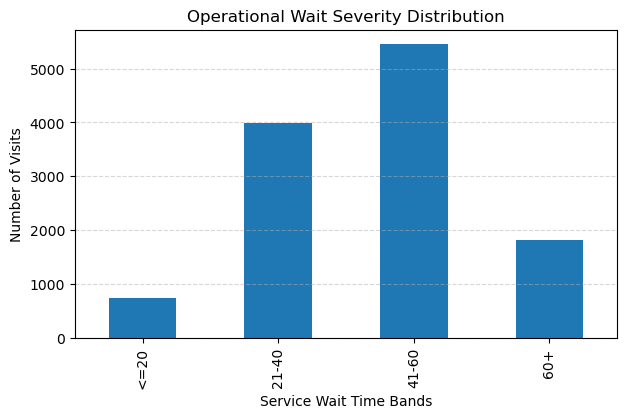

In [79]:
# Waiting-Time Severity Banding
wait_severity = df['wait_band'].value_counts().sort_index()
display(wait_severity)

plt.figure(figsize=(7, 4))
wait_severity.plot(kind='bar')
plt.title('Operational Wait Severity Distribution')
plt.xlabel('Service Wait Time Bands')
plt.ylabel('Number of Visits')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


**Observation:** Patient wait times are split into four operational bands (<=20, 21-40, 41-60, 60+).

**Insight:** A significant portion of patients face long wait times, showing clear bottlenecks during peak operational hours.

**Recommendation:** Adjust shift patterns for front-desk and intake staff to better match peak arrival periods.

### 1.4 Regional Catchment Profile Analysis

city
Hyderabad       5225
Secunderabad    2040
Warangal        1780
Karimnagar      1523
Nizamabad       1308
Unknown          124
Name: count, dtype: int64

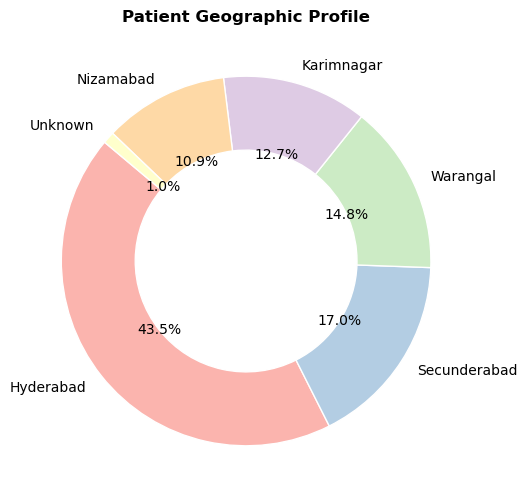

In [80]:
# Patient Profile Analysis (Donut Chart)
city_counts = df['city'].value_counts()
display(city_counts)

plt.figure(figsize=(6, 6))
plt.pie(city_counts.values, labels=city_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=plt.cm.Pastel1.colors, 
        wedgeprops=dict(width=0.4, edgecolor='white'))

plt.title('Patient Geographic Profile', fontsize=12, fontweight='bold')
plt.show()


**Observation:** The regional catchment distribution shows exactly how the primary patient base splits across geographic centers using proportional segment sizes.

**Insight:** Marketing strategies and local outreach efforts are heavily optimized toward specific core areas, leaving surrounding secondary zones open for growth.

**Recommendation:** Set up small satellite collection centers or mobile diagnostic vans in secondary geographic zones to capture more patient volume.

## 2. Bivariate Analysis
- Bivariate analysis compares **two variables** to understand how one business factor changes with another.

### 2.1 Which department has the longest waits?

C:\Users\shash\AppData\Local\Temp\ipykernel_11776\1697814287.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=departments, patch_artist=True,


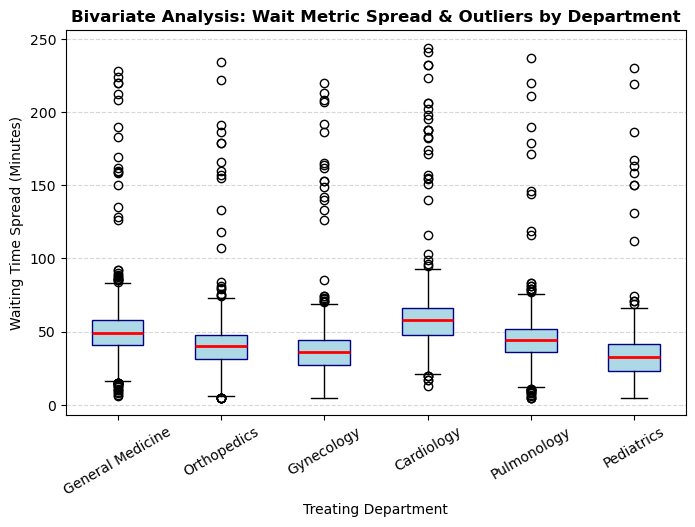

In [81]:
# Department Bottlenecks (Box Plot)
plt.figure(figsize=(8, 5))
# Create list of series arrays safely to feed matplotlib boxplot natively
departments = df['department'].unique()
data_to_plot = [df[df['department'] == dept]['waiting_time_minutes'].dropna().values for dept in departments]

plt.boxplot(data_to_plot, labels=departments, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Bivariate Analysis: Wait Metric Spread & Outliers by Department', fontsize=12, fontweight='bold')
plt.xlabel('Treating Department')
plt.ylabel('Waiting Time Spread (Minutes)')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Observation:** Cardiology has the highest median waiting time and relatively high variability, while Pediatrics has the lowest median. Multiple extreme waiting-time outliers are present across all departments.

**Insight:** The results indicate that Cardiology may have a potential patient-flow bottleneck, while extreme outliers suggest occasional cases of significant delay across departments.

**Recommendation:** Management should investigate the underlying causes of longer waits, particularly in Cardiology, by analyzing patient volume, visit types, and emergency workload. Regular department-level monitoring and appropriate resource allocation can help reduce excessive waiting times.

### 2.2 Departmental Staffing needs

department
General Medicine    3535
Orthopedics         1979
Cardiology          1914
Pulmonology         1631
Gynecology          1489
Pediatrics          1452
Name: count, dtype: int64

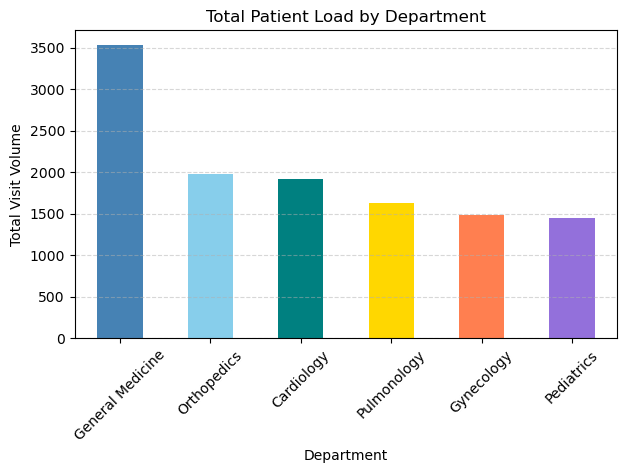

In [82]:
# High-Volume Department Staffing Load
dept_volumes = df['department'].value_counts()
display(dept_volumes)
colors = ['steelblue', 'skyblue', 'teal', 'gold', 'coral','mediumpurple']

plt.figure(figsize=(7, 4))
dept_volumes.plot(kind='bar',color = colors)
plt.title('Total Patient Load by Department')
plt.xlabel('Department')
plt.ylabel('Total Visit Volume')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


**Observation:** Total patient volume varies significantly across specialties, showing a heavy workload concentrated in specific areas like General Medicine.

**Insight:** High-volume departments run a higher risk of staff burnout and longer queues if their capacity isn't balanced with clear staffing schedules.

**Recommendation:** Temporarily reassign cross-trained nursing staff to help high-volume departments handle peak daily rushes.

### 2.3 Does waiting time affect satisfaction?

wait_band
<=20     4.76
21-40    4.56
41-60    4.33
60+      4.03
Name: satisfaction_score, dtype: float64

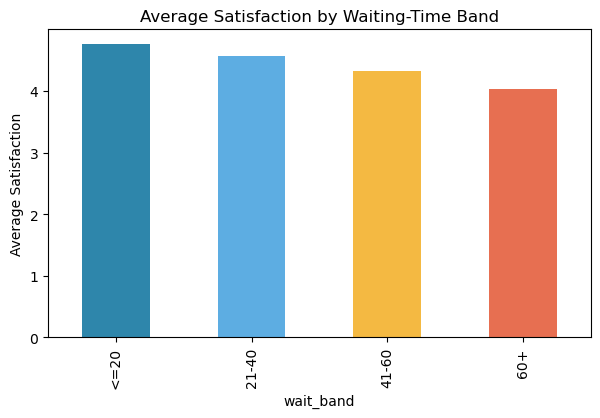

In [83]:
wait_satisfaction = df.groupby('wait_band', observed=True)['satisfaction_score'].mean().round(2)
display(wait_satisfaction)
colors = ['#2E86AB', '#5DADE2', '#F4B942', '#E76F51']

plt.figure(figsize=(7,4))
wait_satisfaction.plot(kind='bar', color = colors)
plt.title('Average Satisfaction by Waiting-Time Band')
plt.ylabel('Average Satisfaction')
plt.show()

**Observation:** Satisfaction declines steadily and monotonically: 4.76 → 4.56 → 4.33 → 4.03 as waiting time increases.

**Insight:** Delays past the 60-minute mark directly harm the patient experience, confirming that longer waits reliably lead to poorer satisfaction scores.

**Recommendation:** Make wait-time reduction the top-priority lever for satisfaction improvement, starting with the 60+ minute segment.

### 2.4 Which visit type drives revenue?


visit_type
Inpatient    28640.869296
Emergency     4723.139667
OPD           2397.324189
Name: bill_amount, dtype: float64

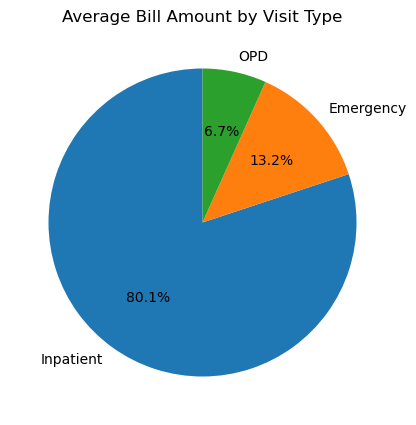

In [84]:
# Billing Value Variations by Visit Type
visit_billing = df.groupby('visit_type')['bill_amount'].mean().sort_values(ascending=False)
display(visit_billing)

plt.figure(figsize=(5,5))
plt.pie(visit_billing, labels=visit_billing.index, autopct='%1.1f%%', startangle=90)
plt.title('Average Bill Amount by Visit Type')
plt.show()

**Observation:** Inpatient stays drive much higher average bill amounts than Emergency and Outpatient (OPD) visits.

**Insight:** Inpatient admissions generate the vast majority of hospital revenue due to longer lengths of stay and more intensive use of resources.

**Recommendation:** Optimize the bed allocation process to keep inpatient workflows smooth and protect your primary revenue driver.

### 2.5 Does chronic condition track with age?

chronic_condition,Asthma,Cardiac,Diabetes,Hypertension,None,Thyroid
age_group,,,,,,
0-17,7.9,2.4,6.2,11.6,69.0,2.9
18-30,8.2,3.0,14.0,10.5,59.4,4.9
31-45,8.9,4.2,14.5,13.9,54.0,4.4
46-60,7.4,8.2,17.1,20.3,39.8,7.2
60+,5.6,11.4,20.5,28.4,28.8,5.3


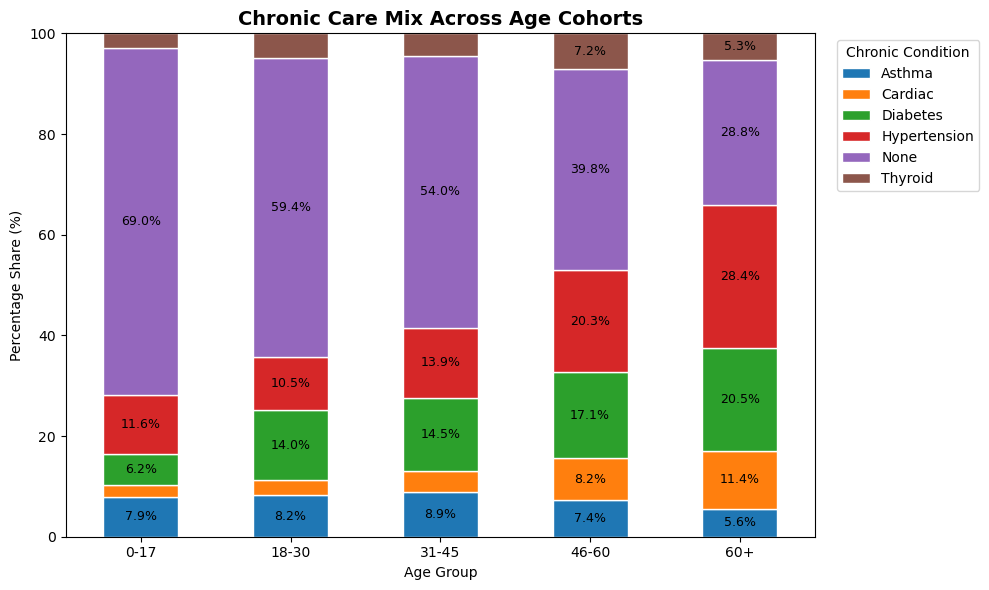

In [85]:
# Chronic Care Distribution Across Generations
age_chronic = pd.crosstab(df['age_group'], df['chronic_condition'], normalize='index') * 100
display(age_chronic.round(1))

ax = age_chronic.plot(kind='bar', stacked=True, figsize=(10, 6), edgecolor='white')
plt.title('Chronic Care Mix Across Age Cohorts', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Percentage Share (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.legend(
    title='Chronic Condition',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
# Add percentage labels
for container in ax.containers:
    labels = [
        f'{bar.get_height():.1f}%' if bar.get_height() >= 5 else ''
        for bar in container
    ]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9)

plt.tight_layout()
plt.show()

**Observation:** The mix of chronic conditions changes clearly across age buckets, with metabolic and cardiovascular issues becoming much more common in older groups.

**Insight:** Older patients require more intensive chronic care, whereas younger age brackets show a larger share of cases without chronic conditions (None).

**Recommendation:** Target preventive screening programs at the 46+ age groups, where chronic-condition load concentrates.Pair senior wellness packages directly with regular diagnostic checks for hypertension and cardiac health.

## 3. Multivariate Analysis
- Now we combine multiple factors to answer more realistic management questions.

### 3.1 Concentrated Waiting Problems (Department & Service Type)

visit_type,Emergency,Inpatient,OPD
department,,,
Cardiology,49.7,57.2,61.6
General Medicine,42.3,47.9,52.3
Gynecology,28.9,34.7,40.0
Orthopedics,30.3,39.6,43.2
Pediatrics,23.7,32.0,36.5
Pulmonology,36.1,42.9,46.7


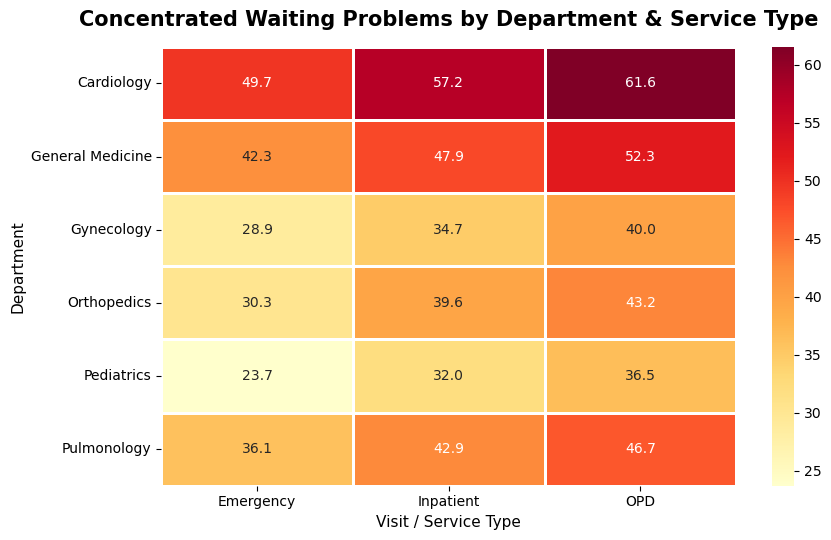

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mean waiting time by Department and Visit Type
wait_pivot = df.pivot_table(
    values='waiting_time_minutes',
    index='department',
    columns='visit_type',
    aggfunc='mean'
)

display(wait_pivot.round(1))

plt.figure(figsize=(9, 5.5))

sns.heatmap(
    wait_pivot,
    annot=True,              # Show values inside cells
    fmt='.1f',               # One decimal place
    cmap='YlOrRd',
    linewidths=2,
    linecolor='white',
)

plt.title('Concentrated Waiting Problems by Department & Service Type', fontsize=15, fontweight='bold', pad=15)

plt.xlabel('Visit / Service Type', fontsize=11)
plt.ylabel('Department', fontsize=11)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**bservation:** The most serious combination is **Cardiology - OPD**, with an average wait of around **61.6 minutes** and satisfaction around **4.18/5**.

**Insight:** High wait times are rarely uniform; they are driven by specific bottlenecks in particular department-service combinations.The problem is more specific than saying “Cardiology is slow.

**Recommendation:** Deploy dedicated emergency triage coordinators in the departments flagged with the longest emergency delays to accelerate care. Start improvement work with the exact department-service combination rather than applying the same solution to the whole hospital.


### 3.2 When does hospital demand peak?


visit_date
2025-07-23    29
2025-01-01    29
2024-04-10    28
2025-01-05    28
2024-01-09    27
              ..
2024-07-04     7
2025-07-14     7
2024-11-18     7
2024-03-27     7
2024-04-17     6
Name: count, Length: 730, dtype: int64

visit_hour
13    1461
12    1456
11    1333
14    1321
10    1113
15    1095
9      862
16     841
Name: count, dtype: int64

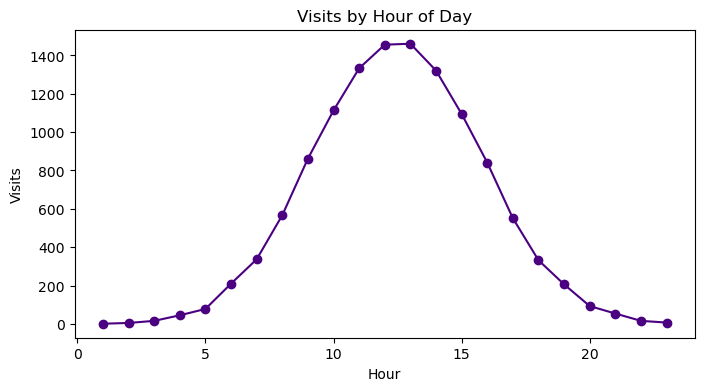

In [87]:
# Peak Demand Volume Shifts by Time Bands
hour_analysis = df['visit_hour'].value_counts().sort_index()
day_analysis = df['visit_date'].value_counts()

display(day_analysis)
display(hour_analysis.sort_values(ascending=False).head(8))

plt.figure(figsize=(8,4))
hour_analysis.plot(kind='line', marker='o',color='indigo')
plt.title('Visits by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Visits')
plt.show()


**Observation:** Patient volume changes sharply throughout the day, showing clear peaks during particular time blocks (like Morning or Midday).

**Insight:** Daily arrival spikes create severe operational strain if clinic staffing levels remain flat across the whole day.

**Recommendation:** Switch to staggered, flexible shifts for medical staff so that maximum coverage aligns perfectly with peak morning and midday surges.

### 3.3 Repeat-Patient Utilization Impact

repeat_patient,Repeat,Single Visit
insurance_status,,
Government Scheme,93.644068,6.355932
Insured,95.125209,4.874791
Self Pay,95.110654,4.889346


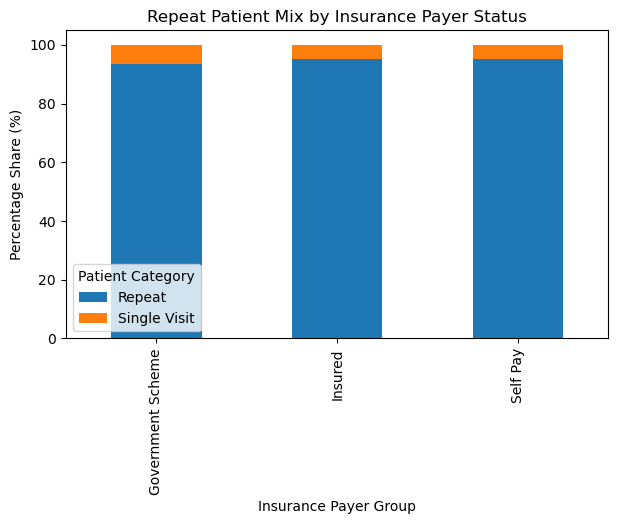

In [88]:
# Repeat Utilization Trends across Payer Groups
utilization_mix = pd.crosstab(df['insurance_status'], df['repeat_patient'], normalize='index') * 100
display(utilization_mix)

utilization_mix.plot(kind='bar', stacked=True, figsize=(7, 4))
plt.title('Repeat Patient Mix by Insurance Payer Status')
plt.xlabel('Insurance Payer Group')
plt.ylabel('Percentage Share (%)')
plt.legend(title='Patient Category')
plt.show()


**Observation:** Repeat visits make up a significant portion of the total volume, with varying rates of return across different insurance groups.

**Insight:** Patients with structured coverage (like Government Schemes or private insurance) show stable return rates, highlighting their long-term reliance on the hospital.

**Recommendation:** Launch a proactive primary care management program to help frequently returning patients coordinate their appointments, improving care quality while freeing up capacity.

### 3.4 Which numeric variables actually move together?

,age,bmi,waiting_time_minutes,length_of_stay_days,satisfaction_score,bill_amount,insurance_covered_amount,patient_paid_amount
age,1.00,-0.01,0.00,-0.02,-0.00,-0.02,-0.01,-0.02
bmi,-0.01,1.00,0.00,0.01,0.01,0.00,0.01,-0.01
waiting_time_minutes,0.00,0.00,1.00,-0.03,-0.59,-0.02,-0.03,-0.01
length_of_stay_days,-0.02,0.01,-0.03,1.00,0.02,0.86,0.72,0.72
satisfaction_score,-0.00,0.01,-0.59,0.02,1.00,0.01,0.01,0.02
bill_amount,-0.02,0.00,-0.02,0.86,0.01,1.00,0.72,0.71
insurance_covered_amount,-0.01,0.01,-0.03,0.72,0.01,0.72,1.00,0.21
patient_paid_amount,-0.02,-0.01,-0.01,0.72,0.02,0.71,0.21,1.00


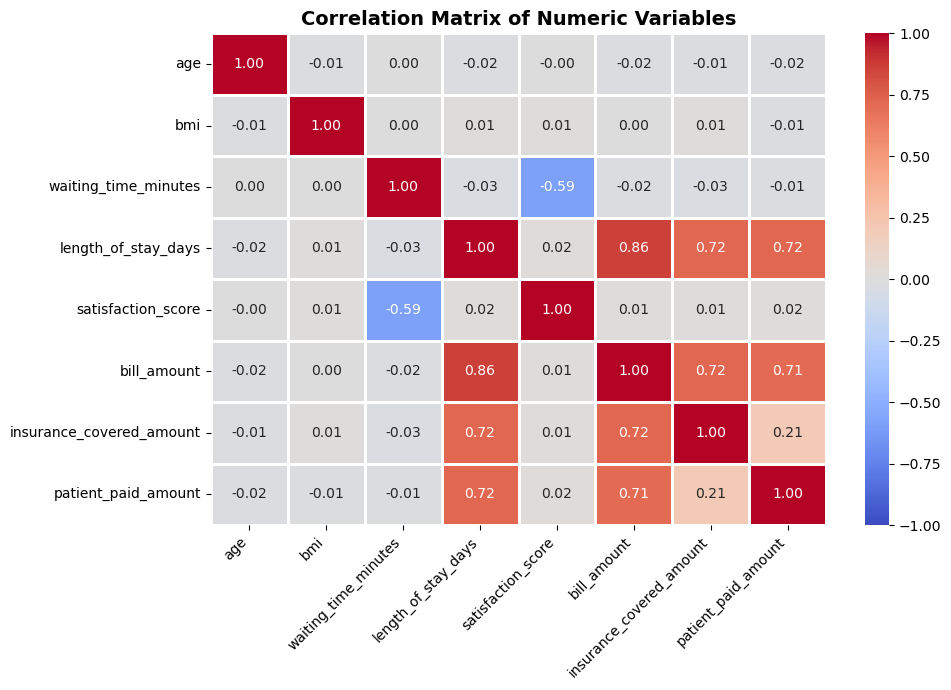

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'age',
    'bmi',
    'waiting_time_minutes',
    'length_of_stay_days',
    'satisfaction_score',
    'bill_amount',
    'insurance_covered_amount',
    'patient_paid_amount',
    
]

corr = df[numeric_cols].corr().round(2)

# Display correlation table
display(corr)

# Plot correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,              # values inside each cell
    fmt='.2f',               # show 2 decimal places
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=1,
    linecolor='white',
    )

plt.title('Correlation Matrix of Numeric Variables', fontsize=14, fontweight='bold')
plt.xticks(rotation=45,  ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Observation:** Only the financial and stay variables correlate meaningfully: length_of_stay ↔ patient_paid (0.72), bill ↔ patient_paid (0.71), insurance_covered ↔ out_of_pocket% (-0.35). Age, BMI and waiting time are near zero against everything.

**Insight:** A correlation matrix only detects linear relationships and can't see categorical variables — which is exactly why waiting time looks unimportant here despite being the strongest driver found in 2.1.

**Recommendation:** Use this matrix to screen for redundant numeric features in any model, but don't rely on it alone to rule variables in or out — confirm with grouped comparisons as well.

# 4. Project Summary
- Data: 4,010 patients, ~12,000 visits, cleaned and merged into one master table with 27 features covering demographics, operations, and billing.

#### What the Analysis Told Us

- **Who the hospital serves :** 
Mostly middle-aged/older (46–60 largest group); General Medicine has the highest patient load; Hyderabad is the core catchment, with smaller secondary cities.

- **The waiting-time problem is real and specific :** 
Not a uniform problem — concentrated in Cardiology + OPD (~61.6 min avg, worst in the hospital), with demand spiking at specific times of day (Morning/Midday), so a flat staffing schedule guarantees congestion at those peaks.

- **Waiting time is the clearest driver of patient satisfaction :** 
Falls in a straight line as wait time rises (4.76 → 4.03), and drops sharpest past 60 minutes. This is the strongest, most actionable pattern in the data.

- **Inpatient visits — not volume — drive revenue :** 
Outpatient (OPD) visits are the majority by count, but Inpatient stays generate the largest bills because they involve longer stays and more resource use. They need to be managed with different goals: throughput for OPD, efficiency and bed management for Inpatient.

- **Chronic conditions concentrate in older patients :** 
As age increases, chronic conditions (especially cardiovascular and metabolic ones like hypertension and diabetes) become far more common.This is a normal, expected clinical pattern — but it means preventive and chronic-care programs will get the most value if they're targeted at the 46+ age group specifically, rather than applied hospital-wide.

- **Repeat patients are the backbone of hospital volume :** 
A large share of total visits come from returning patients, and patients with structured coverage (insurance or government schemes) return at stable, predictable rates — showing genuine long-term reliance on the hospital rather than one-off visits.

- **Most numeric variables don't move together :** 
Mostly shows financial variables linked together; wait time looks "unimportant" there despite being the top satisfaction driver — a reminder not to trust correlation alone.

## 5. Final Recommendations (in priority order)

- **1. Fix Cardiology–OPD scheduling first**. It's the single most severe bottleneck (~61.6 min average wait) and directly drags down satisfaction in that segment. Start here rather than applying a hospital-wide fix.

- **2. Move front-desk and clinical staffing to match real demand**. Since patient arrivals spike at specific times of day (not evenly spread), switch from flat shift patterns to staggered shifts aligned with the Morning/Midday surge.

- **3. Treat wait-time reduction as the top lever for patient satisfaction**. No other factor in the data moves satisfaction as reliably or as strongly — prioritize this over other experience initiatives.

- **4. Manage Inpatient care as the primary revenue driver, separately from OPD volume**. Protect and optimize bed allocation and inpatient workflow specifically, since that's where the money is — don't let General Medicine's high OPD traffic overshadow it in planning.

- **5. Cross-train and reassign nursing staff toward high-volume departments** (like General Medicine) during peak periods, rather than hiring more permanent headcount everywhere.

- **6. Target chronic-care and preventive screening programs at patients aged 46+**, where hypertension, diabetes, and cardiac conditions concentrate — this is a much more efficient use of screening resources than a blanket program.

- **7. Build a proactive care-coordination program for repeat patients**, especially those with government scheme or insurance coverage, since they represent stable, recurring hospital reliance — this improves their care continuity while easing pressure on walk-in capacity.

- **8. Consider expanding reach into secondary cities** (Karimnagar, Nizamabad, Warangal, etc.) via satellite centers or mobile diagnostic units, since patient volume there is comparatively low relative to the core Hyderabad base.